In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

### 1. Linear Model 
Define $\hat{f}(X) = X \cdot \underline{\theta}$. 

Let $p$ be the number of features (not including the intercept term). Let $n$ be the number of training examples.

The matrix form is: 
$$
    \hat{f}(X) = X \cdot \underline{\theta}
    \;=\;
    \begin{bmatrix}
    1 & x_{1,1} & x_{1,2} & ... & x_{1,n} \\
    1 & x_{2,1} & x_{2,2} & ... & x_{2,n} \\
    ... & ... & ... & ... & ... \\
    1 & x_{n,1} & x_{n,2} & ... & x_{n,n} \\
    \end{bmatrix}_{n \times (p+1)} 
    \cdot
    \begin{bmatrix}
    \theta_0 \\
    \theta_1 \\
    \theta_2 \\
    ... \\
    \theta_n \\
    \end{bmatrix}_{(p+1) \times 1} 
    \;=\;
    \begin{bmatrix}
    1 \cdot \theta_0 + x_{1,1} \cdot \theta_1 + x_{1,2} \cdot \theta_2 + ... + x_{1,n} \cdot \theta_n \\
    1 \cdot \theta_0 + x_{2,1} \cdot \theta_1 + x_{2,2} \cdot \theta_2 + ... + x_{2,n} \cdot \theta_n \\
    ... \\
    1 \cdot \theta_0 + x_{n,1} \cdot \theta_1 + x_{n,2} \cdot \theta_2 + ... + x_{n,n} \cdot \theta_n \\
    \end{bmatrix}_{n \times 1} 
    \;=\;
    \begin{bmatrix}
    \hat{f}(x_{1}) \\
    \hat{f}(x_{2}) \\
    ... \\
    \hat{f}(x_{n}) \\
    \end{bmatrix}_{n \times 1}
$$

Note that each row in $\hat{f}(X)$ corresponds to one training example, and these are linear combinations of the features $x_{i,j}$ and parameters $\theta_j$.
### 2. Loss function
Define SSE loss: $J(\underline{\theta}) = \sum_{i=1}^{m} (\hat{f}(x_{i}) - y_{i})^2$
In matrix form:
$$
    J(\underline{\theta}) 
    \;=\; 
    \frac{\partial}{\partial\underline{\theta}} \left[ (X \cdot \underline{\theta} - \underline{y})_{(n \times 1)}^\top \cdot (X \cdot \underline{\theta} - \underline{y})_{(n \times 1)} \right]_{1 \times 1}
    \;=\; 
    \frac{\partial}{\partial\underline{\theta}} \left[ \sum_{i=1}^{n} (\hat{f}(x_{i}) - \underline{y})_i^2 \right]
$$

### 3. Gradient Descent
Update rule: ($\theta^{i}$ denotes the parameter at $i$-th iteration!)

$$ 
    \underline{\theta}^{i+1} = \underline{\theta}^{i} - \alpha \left[ \sum_{i=1}^{n} (X \cdot \underline{\theta}^{i} - \underline{y}) \cdot X_{i} \right]
$$

data shapes:X=(100, 1) y=(100, 1)
m (samples)=100, p (features)=1
X_b shape (with bias)=(100, 2)
[1901881.7583670663, 844164.4078937275, 811552.5632997688, 810333.8386793154, 810285.55222296, 810283.6099992784, 810283.531586198, 810283.5284175699, 810283.5282894993, 810283.5282843226]


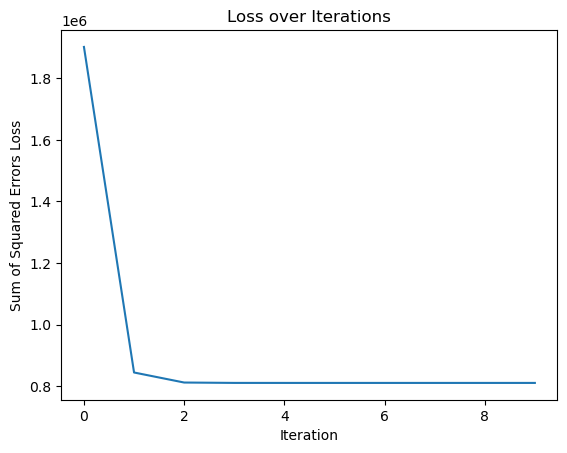

In [67]:
X, y = make_regression(n_samples=100, n_features=1, noise=100)
y = y.reshape(-1, 1) # num responses
# n number of training examples
# p number of features

m = X.shape[0] # num samples
p = X.shape[1] # num features

print("data shapes:X={} y={}".format(X.shape, y.shape))
print("m (samples)={}, p (features)={}".format(m, p))

X_b = np.c_[np.ones((m, 1)), X] # add bias term (intercept) to each instance
print("X_b shape (with bias)={}".format(X_b.shape))

theta = np.random.randn(p + 1, 1)  # Shape: (p+1, 1)
alpha = 0.01 # learning rate
num_iter = 10
losses = []


for _ in range(num_iter): 
    y_pred = X_b.dot(theta) # predictions
    error = y_pred - y # error
    gradients = X_b.T.dot(error) # gradients
    theta -= alpha * gradients # update parameters
    loss = np.sum(error**2) # compute loss, SSE
    losses.append(loss) # record loss

print(losses)
plt.plot(range(num_iter), losses)
plt.xlabel('Iteration')
plt.ylabel('Sum of Squared Errors Loss')
plt.title('Loss over Iterations')
plt.show()

Learned parameters (theta):
[[ -4.47570158]
 [100.46215349]]


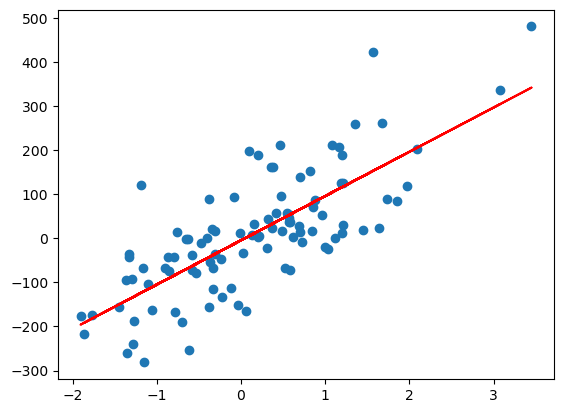

In [68]:
print("Learned parameters (theta):")
print(theta)

plt.scatter(X, y)
plt.plot(X, X.dot(theta[1:]) + theta[0], color='red') # regression line
plt.show()